**Group no : 17**              **IS6061: Python for Business Analytics**

**Student ID:**

Kartik Shah: 124119829,
Sarvesh Pisal: 125119869,
Srushti R Shetti: 125121632,
Aditya More: 125122479,
Gayatri Satyakar: 125104914 &
Sahil Kamble: 125104903


This project focuses on preparing, cleaning, and analysing customer-related datasets to support behavioural insights, segmentation, and predictive modelling. The raw data was provided in three separate files: customer information, customer behaviour, and monthly login activity. Each dataset contained inconsistencies such as missing values, formatting errors, invalid numerical ranges, duplicated customer IDs, and unstandardised text labels. To make the data suitable for analysis and visualisation, we performed a structured data cleaning pipeline that included standardising date formats, correcting categorical fields, validating numerical values based on business rules, reshaping monthly login data, and merging all tables into one unified customer dataset. The cleaned dataset was then enhanced with several derived metrics including financial, temporal, engagement, and segmentation features to support deeper analysis and facilitate the development of dashboards and predictive models. This document explains the complete cleaning process, provides detailed code, and justifies each transformation step undertaken in the project.

The script cleans the raw monthly_logins.csv dataset by standardising inconsistent month column names into a consistent YYYY-MM structure, converting all login counts to numeric values, and replacing invalid entries such as sentinel placeholders (e.g., 999999) and negative numbers with missing values. It also removes unrealistic login counts (greater than 200), rounds values, and reshapes the dataset to remove duplicate customer records. The cleaned data is saved in two formats: a wide format (monthly_logins_clean_wide.csv), and a long format (monthly_logins_clean_long.csv) where each row represents a customer-month login entry. In a second stage, the script replaces missing values with zeros and converts the YYYY-MM column names into MM/YYYY, producing the final file monthly_logins_clean_wide_final.csv used in merging with the other datasets.

In [56]:
import pandas as pd
import numpy as np
import re
import calendar

# Load monthly logins
df_raw = pd.read_csv("monthly_logins.csv")

# Quick look
print(df_raw.shape)
display(df_raw.head())
display(df_raw.info())


# Build a month-name → number map
month_map = {m.lower(): i for i, m in enumerate(calendar.month_abbr) if m}
month_map.update({m.lower(): i for i, m in enumerate(calendar.month_name) if m})

def standardize_month_col(col):
    """Convert messy month columns to YYYY-MM. Leaves CustomerID unchanged."""
    if col == "CustomerID":
        return col

    c = col.strip()

    # unify separators (space, dash) to underscore
    c2 = re.sub(r'[\s\-]+', '_', c)
    c2 = re.sub(r'__+', '_', c2)

    # find patterns: month + year (e.g., Nov_2023, Dec_2024)
    m = re.search(r'([A-Za-z]{3,9})_?(\d{4})', c2)
    if not m:
        return col

    mon_str = m.group(1).lower()
    year = int(m.group(2))

    # use first 3 letters to match month_map
    mon = month_map.get(mon_str[:3], None)
    if mon is None:
        return col

    return f"{year}-{mon:02d}"

# Apply renaming
df = df_raw.copy()
df.columns = [standardize_month_col(c) for c in df.columns]

print(df.columns)

month_cols = [c for c in df.columns if c != "CustomerID"]

df[month_cols] = df[month_cols].apply(pd.to_numeric, errors="coerce")

display(df[month_cols].dtypes.head())


# Replace common sentinel values with NaN
df[month_cols] = df[month_cols].replace({999999: np.nan, 99999: np.nan, 9999: np.nan})

# Negative logins are impossible → NaN
df[month_cols] = df[month_cols].mask(df[month_cols] < 0)

# Cap/Remove extreme values over 200 → NaN (per expected range)
df[month_cols] = df[month_cols].mask(df[month_cols] > 200)


df[month_cols] = df[month_cols].round().astype("Int64")

display(df[month_cols].head())


df_clean = (
    df.groupby("CustomerID", as_index=False)[month_cols]
      .max()
)

print(df_clean.shape)
print(df_clean.duplicated("CustomerID").sum())


sorted_month_cols = sorted(month_cols)
df_clean = df_clean[["CustomerID"] + sorted_month_cols]

display(df_clean.head())


logins_long = df_clean.melt(
    id_vars="CustomerID",
    var_name="Month",
    value_name="LoginCount"
)

# Convert Month to datetime
logins_long["Month"] = pd.to_datetime(logins_long["Month"])

# Drop NaNs (these mean pre-signup months)
logins_long = logins_long.dropna(subset=["LoginCount"])

display(logins_long.head())
print(logins_long.shape)


df_clean.to_csv("monthly_logins_clean_wide.csv", index=False)
logins_long.to_csv("monthly_logins_clean_long.csv", index=False)


import pandas as pd

# Load the cleaned wide dataset you downloaded earlier
df_clean = pd.read_csv("monthly_logins_clean_wide.csv")

## Replace all missing values with 0

df_clean = df_clean.fillna(0)


## Convert column names from YYYY-MM → MM/YYYY

new_columns = []
for col in df_clean.columns:
    if col == "CustomerID":
        new_columns.append(col)
        continue

    # Expecting format YYYY-MM
    try:
        year, month = col.split("-")
        new_format = f"{month}/{year}"
        new_columns.append(new_format)
    except:
        # if anything unexpected appears, leave unchanged
        new_columns.append(col)

df_clean.columns = new_columns

## Save the fully cleaned dataset

df_clean.to_csv("monthly_logins_clean_wide_final.csv", index=False)

print("File saved as monthly_logins_clean_wide_final.csv")
df_clean.head()



(10030, 25)


,CustomerID,nov_2023,Dec-2023,Jan_2024,feb_2024,Mar-2024,Apr_2024,may_2024,Jun-2024,Jul_2024,...,Jan_2025,feb_2025,Mar-2025,Apr_2025,may_2025,Jun-2025,Jul_2025,aug_2025,Sep-2025,Oct_2025
0,1148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,44.0,39.0,38.0,31.0,30.0,39.0,0.0,35.0,35.0,42.0
1,4097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,80.0,72.0,52.0,37.0
2,8238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,12.0
3,32449,179.0,164.0,179.0,146.0,132.0,132.0,97.0,114.0,103.0,...,68.0,69.0,84.0,0.0,76.0,57.0,59.0,47.0,42.0,45.0
4,37330,25.0,25.0,0.0,27.0,33.0,0.0,32.0,26.0,36.0,...,33.0,41.0,40.0,0.0,46.0,43.0,42.0,42.0,49.0,36.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10030 entries, 0 to 10029
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  10030 non-null  int64 
 1   nov_2023    4434 non-null   object
 2   Dec-2023    4675 non-null   object
 3   Jan_2024    4914 non-null   object
 4   feb_2024    5165 non-null   object
 5   Mar-2024    5379 non-null   object
 6   Apr_2024    5602 non-null   object
 7   may_2024    5839 non-null   object
 8   Jun-2024    6079 non-null   object
 9   Jul_2024    6329 non-null   object
 10  aug_2024    6571 non-null   object
 11  Sep-2024    6838 non-null   object
 12  Oct_2024    7092 non-null   object
 13  nov_2024    7338 non-null   object
 14  Dec-2024    7583 non-null   object
 15  Jan_2025    7830 non-null   object
 16  feb_2025    8081 non-null   object
 17  Mar-2025    8276 non-null   object
 18  Apr_2025    8519 non-null   object
 19  may_2025    8747 non-null   object
 20  Jun-20

None

Index(['CustomerID', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03',
       '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09',
       '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03',
       '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09',
       '2025-10'],
      dtype='object')


...

(10000, 25)
0


,CustomerID,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,...,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10
0,2,41,37,36,39,46,37,0,41,36,...,41,41,39,40,49,41,49,43,0,41
1,5,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,42,32,28,29,30,21,28,26,23,17
2,8,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,40,48,<NA>,38,37,37,36,42,48
3,12,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,18,12,...,12,11,11,8,8,7,7,10,9,0
4,14,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,65,68,59,44,35,31,32


,CustomerID,Month,LoginCount
0,2,2023-11-01,41
5,24,2023-11-01,48
10,58,2023-11-01,82
11,67,2023-11-01,69
12,77,2023-11-01,11


(170043, 3)
File saved as monthly_logins_clean_wide_final.csv


,CustomerID,11/2023,12/2023,01/2024,02/2024,03/2024,04/2024,05/2024,06/2024,07/2024,...,01/2025,02/2025,03/2025,04/2025,05/2025,06/2025,07/2025,08/2025,09/2025,10/2025
0,2,41.0,37.0,36.0,39.0,46.0,37.0,0.0,41.0,36.0,...,41.0,41.0,39.0,40.0,49.0,41.0,49.0,43.0,0.0,41.0
1,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,42.0,32.0,28.0,29.0,30.0,21.0,28.0,26.0,23.0,17.0
2,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,40.0,48.0,0.0,38.0,37.0,37.0,36.0,42.0,48.0
3,12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,12.0,...,12.0,11.0,11.0,8.0,8.0,7.0,7.0,10.0,9.0,0.0
4,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,65.0,68.0,59.0,44.0,35.0,31.0,32.0


The Python script reads the raw customer_info.csv file and produces a fully cleaned version called customer_info_clean_fullTextContractLength.csv. It standardises the CustomerID field, trims extra spaces, recodes categorical columns (such as Gender, Region, Education, CustomerSegment, ContractLength, PlanType, PaymentMethod, IncomeTier and AutoPay) into consistent labels, converts dates and numeric fields into the correct data types, removes implausible outliers, imputes remaining missing values, removes duplicate customer records, formats the contract start date into a uniform DD/MM/YY format, and finally saves the cleaned dataset for further analysis.

In [57]:
## Load original data

import pandas as pd
import numpy as np
import re

  ## Reads the original raw file customer_info.csv into df_raw.
df_raw = pd.read_csv("customer_info.csv")
  ## Copies it to df so you keep the original untouched.
df = df_raw.copy()

## Clean CustomerID

def clean_customer_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s = re.sub(r'(?i)^CUST', '', s).strip()
    return int(s) if s.isdigit() else np.nan

  ## Finally stores the result as pandas nullable integer type Int64.
df["CustomerID"] = df["CustomerID"].apply(clean_customer_id).astype("Int64")

## Strip whitespace from all string columns

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

  ## Maps small integers (0–12) to words like "one", "two", etc.

def number_to_words(num: int) -> str:
    words = {
        0: "zero",
        1: "one",
        2: "two",
        3: "three",
        4: "four",
        5: "five",
        6: "six",
        7: "seven",
        8: "eight",
        9: "nine",
        10: "ten",
        11: "eleven",
        12: "twelve"
    }
    return words.get(num, str(num))

## Cleaning each categorical column
  ## Gender

def clean_gender(x):
    s = str(x).lower()
    if s in ["m", "male"]:
        return "Male"
    if s in ["f", "female"]:
        return "Female"
    return np.nan

df["Gender"] = df["Gender"].apply(clean_gender)

## Region

def clean_region(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower()

    if s in ["unknown", "na", "n/a", "none", ""]:
        return np.nan

    mapping = {
        "north": "North",
        "south": "South",
        "east": "East",
        "west": "West",
        "central": "Central"
    }
    if s in mapping:
        return mapping[s]

    if s in ["n", "no"]: return "North"
    if s in ["s", "so"]: return "South"
    if s == "e": return "East"
    if s == "w": return "West"
    if s == "c": return "Central"

    return np.nan

df["Region"] = df["Region"].apply(clean_region)

## Education
def clean_education(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()

    if s.lower() in ["unknown", "na", "n/a", "none", ""]:
        return np.nan

    if s.isdigit():
        return f"{number_to_words(int(s))} years"

    s2 = s.lower().replace("-", " ")
    if s2 in ["hs", "high school"]:
        return "High School"
    if s2.startswith("dip"):
        return "Diploma"
    if s2.startswith("bachelor"):
        return "Bachelor"
    if s2.startswith("master"):
        return "Master"
    if s2.startswith("ph"):
        return "PhD"

    return np.nan

df["Education"] = df["Education"].apply(clean_education)

## CustomerSegment
def clean_segment(x):
    if pd.isna(x): return np.nan
    s = str(x).lower()
    if "bronze" in s: return "Bronze"
    if "silver" in s: return "Silver"
    if "gold" in s: return "Gold"
    if "platinum" in s: return "Platinum"
    if "diamond" in s: return "Diamond"
    return np.nan

df["CustomerSegment"] = df["CustomerSegment"].apply(clean_segment)

## ContractLength (FULL TEXT, NO NUMBERS)
def clean_contract_length(x):
    if pd.isna(x):
        return np.nan

    s = str(x).lower()

    # Month-to-month
    if s in ["m2m", "mtm", "month-to-month", "month to month", "monthly"]:
        return "Month-to-month"

    # match "3 year", "3-year", "3 years"
    year = re.search(r"(\d+)\s*[- ]*\s*year", s)
    if year:
        n = int(year.group(1))
        return f"{number_to_words(n).capitalize()} year"

    years = re.search(r"(\d+)\s*[- ]*\s*years", s)
    if years:
        n = int(years.group(1))
        return f"{number_to_words(n).capitalize()} years"

    # months → years
    month = re.search(r"(\d+)\s*month", s)
    if month:
        m = int(month.group(1))
        if m % 12 == 0:
            return f"{number_to_words(m//12).capitalize()} year"
        else:
            return f"{number_to_words(m).capitalize()} months"

    return s.capitalize()

df["ContractLength"] = df["ContractLength"].apply(clean_contract_length)

## PlanType
def clean_plan_type(x):
    if pd.isna(x): return np.nan
    s = str(x).lower()
    if "basic" in s: return "Basic"
    if "std" in s or "standard" in s: return "Standard"
    if "prem" in s or "premium" in s: return "Premium"
    if "ultra" in s: return "Ultra"
    return str(x).title()

df["PlanType"] = df["PlanType"].apply(clean_plan_type)

## PaymentMethod
def clean_payment(x):
    if pd.isna(x): return np.nan
    s = str(x).lower().replace("_", " ")
    if "credit" in s: return "Credit Card"
    if "bank" in s or "transfer" in s: return "Bank Transfer"
    if "electronic" in s or "echeck" in s or "e-check" in s: return "Electronic Check"
    if "paypal" in s: return "PayPal"
    return "Other"

df["PaymentMethod"] = df["PaymentMethod"].apply(clean_payment)

## IncomeTier
def clean_income_tier(x):
    if pd.isna(x): return np.nan
    s = str(x).lower()
    if s.startswith("low"): return "Low"
    if s.startswith("medium"): return "Medium"
    if "very" in s and "high" in s: return "Very High"
    if s.startswith("high"): return "High"
    return np.nan

df["IncomeTier"] = df["IncomeTier"].apply(clean_income_tier)

## AutoPay
def clean_autopay(x):
    if pd.isna(x): return np.nan
    s = str(x).lower()
    if s in ["yes", "y", "true", "1"]: return "Yes"
    if s in ["no", "n", "false", "0"]: return "No"
    return np.nan

df["AutoPay"] = df["AutoPay"].apply(clean_autopay)

## Converts dates and numeric flields

df["ContractStartDate"] = pd.to_datetime(
    df["ContractStartDate"],
    dayfirst=True,
    errors="coerce"
)

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["TenureMonths"] = pd.to_numeric(df["TenureMonths"], errors="coerce")
df["MonthlyValue"] = (
    df["MonthlyValue"].astype(str)
    .str.replace(r"[^0-9.\-]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

## Outlier handling
df.loc[(df["Age"] < 18) | (df["Age"] > 100), "Age"] = np.nan
df.loc[(df["TenureMonths"] < 0) | (df["TenureMonths"] > 120), "TenureMonths"] = np.nan
df.loc[(df["MonthlyValue"] < 20) | (df["MonthlyValue"] > 200), "MonthlyValue"] = np.nan

## Imputes missing values
for col in ["Age", "TenureMonths", "MonthlyValue"]:
    df[col] = df[col].fillna(df[col].median())

for col in [
    "Gender", "Region", "Education", "CustomerSegment",
    "ContractLength", "PlanType", "PaymentMethod",
    "IncomeTier", "AutoPay"
]:
    mode_val = df[col].mode(dropna=True)
    if len(mode_val) > 0:
        df[col] = df[col].fillna(mode_val.iloc[0])

## Removes duplicate customers

df = df.sort_values("CustomerID").drop_duplicates("CustomerID")

## Format DATE as DD/MM/YY

df["ContractStartDate"] = df["ContractStartDate"].dt.strftime("%d/%m/%y")

## Saves final cleaned dataset
df.to_csv("customer_info_clean_fullTextContractLength.csv", index=False)

print("Cleaning complete!")
print(df.head())



Cleaning complete!
      CustomerID  Churn   Age  Gender   Region Education CustomerSegment  \
6117           2      0  69.0  Female    North   Diploma          Silver   
480            5      0  60.0  Female     East  Bachelor          Bronze   
3533           8      0  38.0  Female     East  Bachelor            Gold   
8838          12      0  49.0    Male  Central   Diploma          Silver   
7578          14      1  28.0  Female  Central   Diploma          Silver   

      ContractLength ContractStartDate  PlanType  TenureMonths  MonthlyValue  \
6117  Month-to-month          18/12/22  Standard          97.0        131.96   
480         One year          23/12/24     Ultra          27.0        134.06   
3533      Three year          28/01/25     Basic          60.0        178.24   
8838  Month-to-month          03/05/24     Ultra          49.0         90.88   
7578        One year          12/03/25     Basic          19.0        104.41   

         PaymentMethod PaymentDelinquencySt

/tmp/ipython-input-206040590.py:216: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["ContractStartDate"] = pd.to_datetime(


This script cleans the customer_behavior.csv dataset by standardising column names, fixing date formats, converting the monthly cost to a numeric EUR field, applying business-defined numeric ranges, normalising categorical fields, correcting inconsistent labels, and rounding numeric values. It also converts the last login date into a uniform DD/MM/YYYY format, sorts customers by ID for consistency, and exports a fully cleaned file named customer_behavior_cleaned_sorted.csv. The resulting dataset is now ready for merging, analysis, modelling, and visualisation.

In [58]:
import pandas as pd
import numpy as np

## Loads the raw dataset customer_behavior.csv into df_clean.

df_clean = pd.read_csv("customer_behavior.csv")

## Basic structural cleaning and type fixes

df_clean.columns = df_clean.columns.str.strip()
df_clean["LastLoginDate"] = pd.to_datetime(df_clean["LastLoginDate"], errors="coerce")


## CLEAN MonthlyValue → MonthlyCost_EUR (numeric)

df_clean["MonthlyCost_EUR"] = (
    df_clean["MonthlyValue"].astype(str).str.replace(r"[^\d\.\-]", "", regex=True)
)
df_clean["MonthlyCost_EUR"] = pd.to_numeric(df_clean["MonthlyCost_EUR"], errors="coerce")
df_clean.drop(columns=["MonthlyValue"], inplace=True)

## Apply business-rule numeric ranges

df_clean["LoginsLastMonth"] = df_clean["LoginsLastMonth"].clip(0, 100)
df_clean["UsageChangePct"] = df_clean["UsageChangePct"].clip(-1, 1)
df_clean["CompetitorIndex"] = df_clean["CompetitorIndex"].clip(0, 1)
df_clean["TicketsResolutionTime"] = df_clean["TicketsResolutionTime"].clip(0, 100)

# TicketsOpened: 0–30
df_clean["TicketsOpened"] = df_clean["TicketsOpened"].clip(0, 30)

# RFMScore: keep only 1–20, then fill with median
df_clean["RFMScore"] = df_clean["RFMScore"].where(df_clean["RFMScore"].between(1, 20))
rfm_median = int(round(df_clean["RFMScore"].median()))
df_clean["RFMScore"] = df_clean["RFMScore"].fillna(rfm_median).astype(int)

# MonthlyCost_EUR: enforce 10–150 EUR range
df_clean["MonthlyCost_EUR"] = df_clean["MonthlyCost_EUR"].clip(10, 150)

## Cleans categorical variables

def norm_text(s):
    return s.astype(str).str.strip().str.title()

# ComplaintCategory
df_clean["ComplaintCategory"] = norm_text(df_clean["ComplaintCategory"])
allowed_c = {"Technical", "Billing", "Service", "Account"}
df_clean.loc[~df_clean["ComplaintCategory"].isin(allowed_c), "ComplaintCategory"] = "Other"

# FamilyPlan
fp = df_clean["FamilyPlan"].astype(str).str.strip().str.lower()
df_clean["FamilyPlan"] = np.nan
df_clean.loc[fp.isin(["yes", "y", "1", "true", "t"]), "FamilyPlan"] = "Yes"
df_clean.loc[fp.isin(["no", "n", "0", "false", "f"]), "FamilyPlan"] = "No"
df_clean["FamilyPlan"] = df_clean["FamilyPlan"].fillna("No")

# AddOnBundle
df_clean["AddOnBundle"] = norm_text(df_clean["AddOnBundle"])
df_clean["AddOnBundle"] = df_clean["AddOnBundle"].replace({"Gamer": "Gaming"})
allowed_add = {"Movies", "Sports", "Music", "Security", "Gaming", "Kids", "None"}
df_clean.loc[~df_clean["AddOnBundle"].isin(allowed_add), "AddOnBundle"] = "Other"

# SupportChannelPreferred
df_clean["SupportChannelPreferred"] = norm_text(df_clean["SupportChannelPreferred"])
allowed_sc = {"Phone", "Email", "Chat", "App"}
df_clean.loc[~df_clean["SupportChannelPreferred"].isin(allowed_sc), "SupportChannelPreferred"] = "Other"

## Round all float numerical columns (2 DECIMALS)

float_cols = df_clean.select_dtypes(include="float").columns
df_clean[float_cols] = df_clean[float_cols].round(2)


## Format DATE as DD/MM/YYYY

df_clean["LastLoginDate"] = df_clean["LastLoginDate"].dt.strftime("%d/%m/%Y")

## Sort by CustomerID ascending & reset index

df_clean = df_clean.sort_values(by="CustomerID", ascending=True).reset_index(drop=True)

## Save final cleaned file

df_clean.to_csv("customer_behavior_cleaned_sorted.csv", index=False)

print("✅ CLEANING COMPLETE!")
print("✅ File saved as: customer_behavior_cleaned_sorted.csv")
df_clean.head()

/tmp/ipython-input-3335687991.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Yes' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_clean.loc[fp.isin(["yes", "y", "1", "true", "t"]), "FamilyPlan"] = "Yes"


✅ CLEANING COMPLETE!
✅ File saved as: customer_behavior_cleaned_sorted.csv


,CustomerID,LoginsLastMonth,LastLoginDate,RFMScore,UsageChangePct,CompetitorIndex,TicketsOpened,TicketsResolutionTime,ComplaintCategory,FamilyPlan,AddOnBundle,SupportChannelPreferred,MonthlyCost_EUR
0,2,44.0,30/09/2025,7,-0.15,0.62,6,46.03,Other,No,Sports,Phone,150.0
1,5,37.0,13/09/2025,13,-0.48,0.11,15,38.54,Technical,No,Other,Phone,150.0
2,8,31.0,23/09/2025,8,0.54,0.30,3,24.23,Technical,No,Movies,Email,150.0
3,12,13.0,07/07/2025,10,-0.48,0.53,13,48.89,Service,No,Movies,Phone,150.0
4,14,50.0,11/05/2025,14,-0.88,0.41,12,37.39,Technical,Yes,Kids,Phone,150.0


This script merges the three previously cleaned datasets—customer information, customer behaviour, and monthly login history—into a single master dataset and then creates a set of derived analytical fields. The merging process ensures only customers present in both information and behaviour tables are retained, while all login data for those customers is included. After merging, the script computes financial metrics such as revenue, profit and margin; temporal metrics such as days since signup and season of signup; engagement metrics like login activity and support intensity; and segmentation fields such as tenure group, age group, value segment and profitability segment. Temporary processing columns are removed, and the final fully enriched dataset is saved as customer_full_merged_with_derived.csv, ready for analysis, modelling and visualisation.

In [59]:
import pandas as pd
import numpy as np
import re
from datetime import datetime

## Loads the cleaned customer_info, customer_behavior and monthly_logins datasets into memory.

info = pd.read_csv("customer_info_clean_fullTextContractLength.csv")
behavior = pd.read_csv("customer_behavior_cleaned_sorted.csv")
logins = pd.read_csv("monthly_logins_clean_wide_final.csv")

## Merges customer_info + customer_behavior

merged = info.merge(
    behavior,
    on="CustomerID",
    how="inner",
    suffixes=("_info", "_beh")
)

## Merges the result with monthly logins

merged = merged.merge(
    logins,
    on="CustomerID",
    how="left"
)

## Create all derived fields

df = merged.copy()

# --- Financial Metrics ---
df["MonthlyRevenue"] = df["MonthlyValue"]
df["MonthlyCost"] = df["MonthlyCost_EUR"]

df["TotalLifetimeRevenue"] = df["MonthlyRevenue"] * df["TenureMonths"]
df["MonthlyProfit"] = df["MonthlyRevenue"] - df["MonthlyCost"]
df["ProfitMargin"] = np.where(
    df["MonthlyRevenue"] > 0,
    (df["MonthlyProfit"] / df["MonthlyRevenue"]) * 100,
    np.nan
)
df["AnnualRevenue"] = df["MonthlyRevenue"] * 12


# --- Temporal Metrics ---
df["ContractStartDate_parsed"] = pd.to_datetime(
    df["ContractStartDate"], dayfirst=True, errors="coerce"
)
df["LastLoginDate_parsed"] = pd.to_datetime(
    df["LastLoginDate"], dayfirst=True, errors="coerce"
)

reference_date = datetime(2025, 10, 3)

df["DaysSinceSignup"] = (reference_date - df["ContractStartDate_parsed"]).dt.days
df["DaysSinceLastLogin"] = (reference_date - df["LastLoginDate_parsed"]).dt.days

df["AgeAtSignup"] = df["Age"] - (df["TenureMonths"] / 12)

df["SignupSeason"] = "Q" + df["ContractStartDate_parsed"].dt.quarter.astype("Int64").astype(str)


# --- Engagement Metrics ---
df["SupportIntensity"] = df["TicketsOpened"] / df["TenureMonths"].replace({0: np.nan})

# identify monthly login columns (MM/YYYY)
login_cols = [c for c in df.columns if re.fullmatch(r"\d{2}/\d{4}", c)]

# sort them chronologically
login_cols_sorted = sorted(
    login_cols,
    key=lambda x: (int(x[3:7]), int(x[0:2]))
)

df[login_cols_sorted] = df[login_cols_sorted].apply(pd.to_numeric, errors="coerce")

df["AverageMonthlyLogins"] = df[login_cols_sorted].mean(axis=1)

if login_cols_sorted:
    df["LoginTrend"] = df[login_cols_sorted[-1]] - df[login_cols_sorted[0]]
else:
    df["LoginTrend"] = np.nan

def customer_status(days):
    if pd.isna(days): return "Unknown"
    if days <= 30: return "Active"
    if days <= 90: return "At Risk"
    return "Inactive"

df["CustomerStatus"] = df["DaysSinceLastLogin"].apply(customer_status)


# --- Segmentation Metrics ---

# Tenure segment
def tenure_segment(months):
    if pd.isna(months): return "Unknown"
    if months < 12: return "New"
    if months < 36: return "Growing"
    if months < 72: return "Established"
    return "Loyal"

df["TenureSegment"] = df["TenureMonths"].apply(tenure_segment)

# Age group (clean version)
def age_group_clean(age):
    if pd.isna(age): return "Unknown"
    if age < 30: return "Under 30"
    if age < 45: return "30-44"
    if age < 60: return "45-59"
    return "60+"

df["AgeGroup"] = df["Age"].apply(age_group_clean)

# Value segment (quartiles of revenue)
try:
    df["ValueSegment"] = pd.qcut(
        df["MonthlyRevenue"],
        4,
        labels=["Low", "Medium", "High", "Very High"]
    )
except ValueError:
    df["ValueSegment"] = pd.cut(
        df["MonthlyRevenue"],
        bins=4,
        labels=["Low", "Medium", "High", "Very High"]
    )

# Profitability segment
profit = df["MonthlyProfit"]
q1 = profit.quantile(0.25)
q3 = profit.quantile(0.75)

def profitability_segment(p):
    if pd.isna(p): return "Unknown"
    if p <= 0: return "Loss-making"
    if p <= q1: return "Low profit"
    if p <= q3: return "Medium profit"
    return "High profit"

df["ProfitabilitySegment"] = df["MonthlyProfit"].apply(profitability_segment)

# remove temp columns
df = df.drop(columns=["ContractStartDate_parsed", "LastLoginDate_parsed"])

## Saves the final merged and enriched dataset

df.to_csv("customer_full_merged_with_derived.csv", index=False)

print("Successfully created: customer_full_merged_with_derived.csv")

/tmp/ipython-input-2050959293.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["ContractStartDate_parsed"] = pd.to_datetime(


Successfully created: customer_full_merged_with_derived.csv


The below code loads a customer dataset from a CSV file and performs an initial exploratory data analysis by showing the first few rows, reporting the dataset’s shape, listing the data types of all columns, and calculating how many missing values each column contains. It also generates descriptive statistics for both numerical and categorical features to give an overview of distributions and data characteristics. Finally, it visualizes missing values with a heatmap, making it easy to identify where any gaps occur across the dataset.

Shape: (10000, 70)

Column Types:
 CustomerID                int64
Churn                     int64
Age                     float64
Gender                   object
Region                   object
                         ...   
CustomerStatus           object
TenureSegment            object
AgeGroup                 object
ValueSegment             object
ProfitabilitySegment     object
Length: 70, dtype: object

Missing Values:
 CustomerID              0
Churn                   0
Age                     0
Gender                  0
Region                  0
                       ..
CustomerStatus          0
TenureSegment           0
AgeGroup                0
ValueSegment            0
ProfitabilitySegment    0
Length: 70, dtype: int64


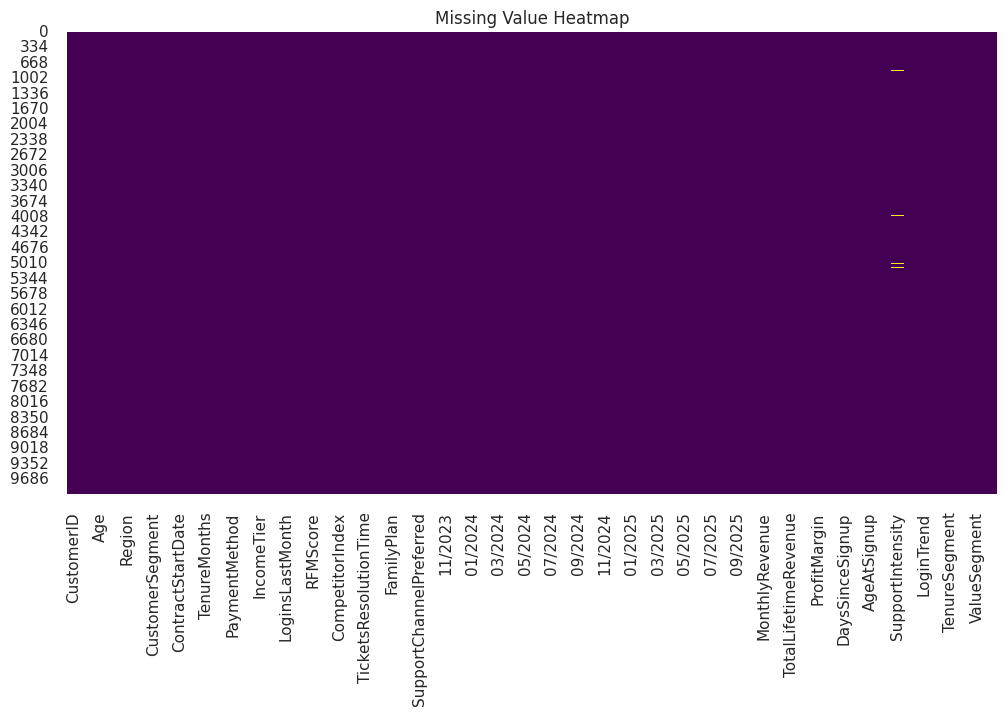

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the merged dataset

df = pd.read_csv("customer_full_merged_with_derived.csv")

df.head()

## Display dataset size and column types

print("Shape:", df.shape)
print("\nColumn Types:\n", df.dtypes)

## Check for missing values

print("\nMissing Values:\n", df.isnull().sum())

## Generate descriptive statistics

df.describe(include='all').T

## Plot a missing-value heatmap

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()




The below code selects only the numerical columns from the dataset and calculates their correlation matrix to understand how different numeric variables relate to each other. It then visualizes these correlations using a heatmap, where stronger positive correlations appear in red and stronger negative correlations in blue, making it easy to spot highly related features, potential multicollinearity, or meaningful relationships between variables.

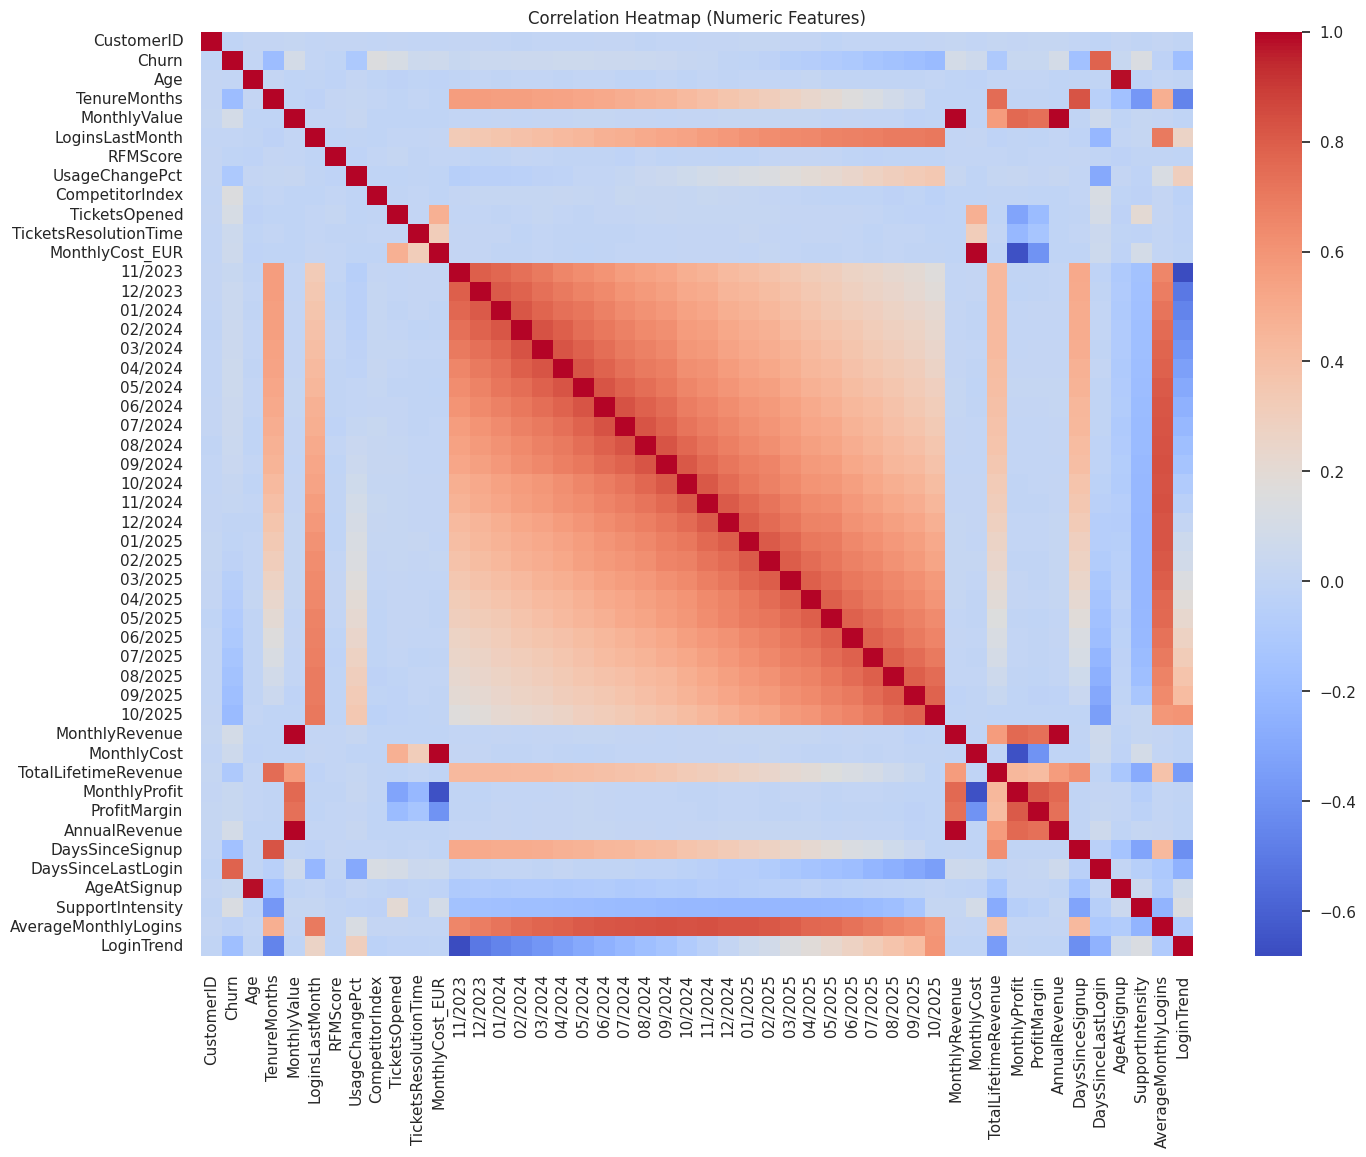

In [61]:

plt.figure(figsize=(16,12))                                                     ## Sets up the plotting canvas
numeric_df = df.select_dtypes(include=['float','int'])                          ## Extracts only columns with numeric data types (integers and floats)
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')                    ## Compute the correlation matrix and plots the heatmap
plt.title("Correlation Heatmap (Numeric Features)")                             ## Labels the plot clearly for interpretation
plt.show()                                                                      ## Renders the plot to the screen


The below script generates a distribution plot for the MonthlyRevenue variable using a histogram combined with a kernel density estimate (KDE). This visualization helps illustrate how monthly revenue values are spread across customers, revealing the central tendency, the shape of the distribution, and whether the data is skewed or contains any noticeable peaks or anomalies.

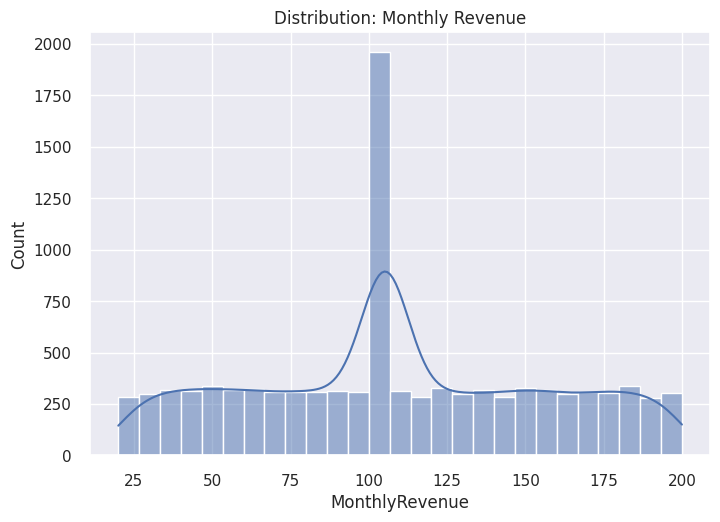

In [62]:

sns.histplot(df["MonthlyRevenue"], kde=True)                                    ## Creates a histogram showing how often each revenue range appears
plt.title("Distribution: Monthly Revenue")                                      ## Labels the chart clearly
plt.show()                                                                      ## Renders the histogram and KDE curve to the screen.


The below code creates a distribution plot for the MonthlyProfit variable by drawing a histogram along with a kernel density estimate, allowing you to examine how profit values are spread across customers. This visualization highlights the shape of the distribution, showing areas where profit is negative, where most values cluster, and how the data tapers off toward higher profit levels, helping identify skewness, peaks, or unusual patterns in profitability.

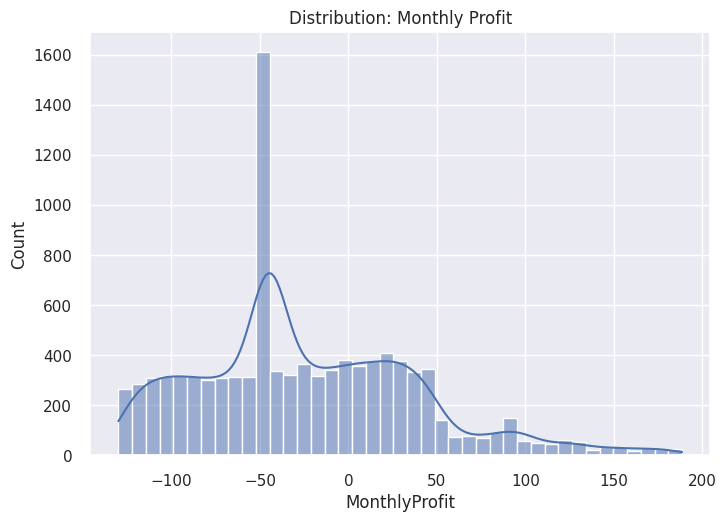

In [63]:

sns.histplot(df["MonthlyProfit"], kde=True)         ## Draws a histogram showing the frequency of different monthly profit levels
plt.title("Distribution: Monthly Profit")           ## Clearly labels the plot, indicating that the chart visualises profit distribution
plt.show()                                          ## Displays the histogram and KDE curve on the screen


The below code visualizes the distribution of the TenureMonths variable by plotting a histogram with a smooth KDE curve on top, allowing you to see how long customers have been with the company and how those tenures are spread across the customer base. This distribution reveals where most customers fall in terms of tenure, highlights any concentrated peaks, such as around the mid-range and shows whether customer tenure is uniform, clustered, or skewed toward shorter or longer membership durations.

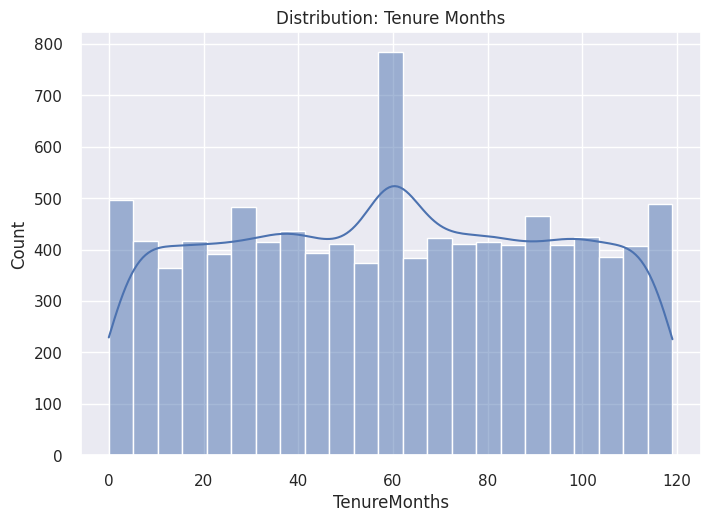

In [64]:

sns.histplot(df["TenureMonths"], kde=True)            ## Creates a histogram showing how many customers fall into each tenure range
plt.title("Distribution: Tenure Months")              ## Clearly labels the chart so the viewer knows the plot is analysing customer tenure
plt.show()                                            ## Renders the histogram and KDE curve on the screen


The below script generates a count plot for the RFMScore variable to show how frequently each score occurs across the customer base. By visualizing the distribution of RFM scores, the plot makes it easy to see which scores are most common, how evenly customers are spread across different scoring levels and whether certain score ranges stand out, helping assess customer value segmentation patterns.

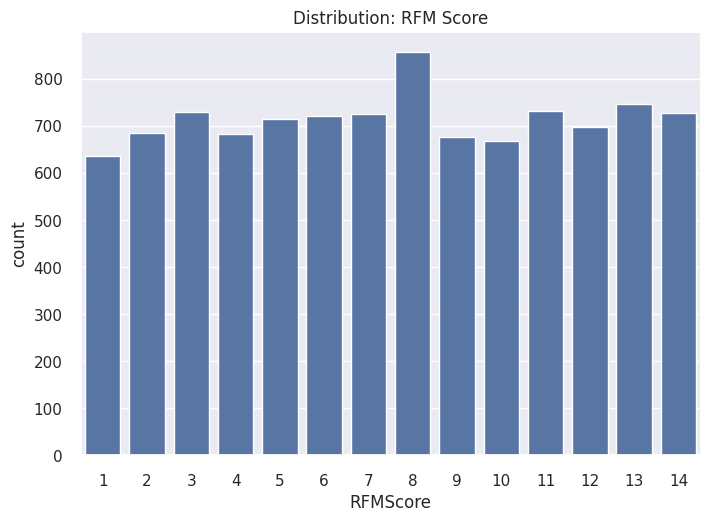

In [65]:

sns.countplot(x=df["RFMScore"])          ## Creates a count plot for RFM Score
plt.title("Distribution: RFM Score")     ## Clearly labels the visualisation so the viewer knows it shows RFM Score distribution.
plt.show()                               ## Renders the count plot on the screen


The below code creates a count plot to visualize how customers are distributed across different age groups. By plotting the frequency of each age category, it clearly shows which age segments make up the largest and smallest portions of the customer base, helping to understand demographic patterns such as whether the customer population is older, younger, or evenly spread across age groups.

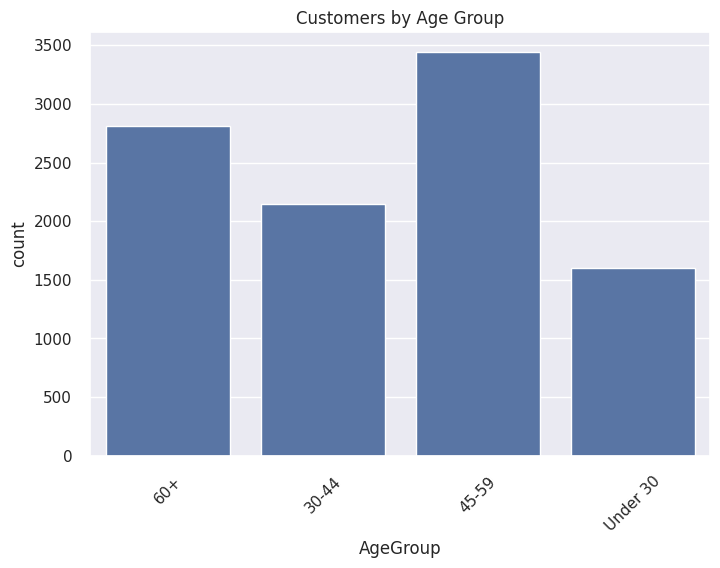

In [66]:

sns.countplot(x=df["AgeGroup"])                                                 ## Generates a count plot of AgeGroup
plt.title("Customers by Age Group")                                             ## Clearly labels the chart to indicate that it shows customer age segmentation
plt.xticks(rotation=45)                                                         ## Rotate x-axis labels for readability
plt.show()                                                                      ## Renders the final count plot on screen


The below code generates a count plot to display how customers are distributed across different TenureSegment categories. This visualization highlights the relative size of each segment such as Loyal, Growing, Established, and New making it easy to see which groups dominate the customer base and how customer tenure related behavior is distributed across the dataset.

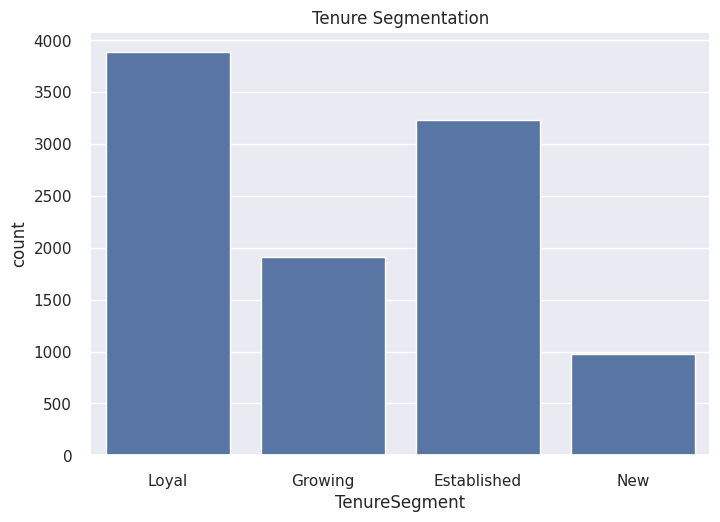

In [67]:

sns.countplot(x=df["TenureSegment"])                       ## Generate a count plot of tenure segments
plt.title("Tenure Segmentation")                           ## Clearly labels the visualisation so the viewer knows it represents customer tenure distribution.
plt.show()                                                 ## Renders the final count plot on screen


The below code creates a count plot to visualize how customers are distributed across different ValueSegment categories. This chart highlights the relative size of each value tier such as High, Very High, Medium and Low making it easy to see which customer value groups are most common and how overall customer value is spread throughout the dataset.

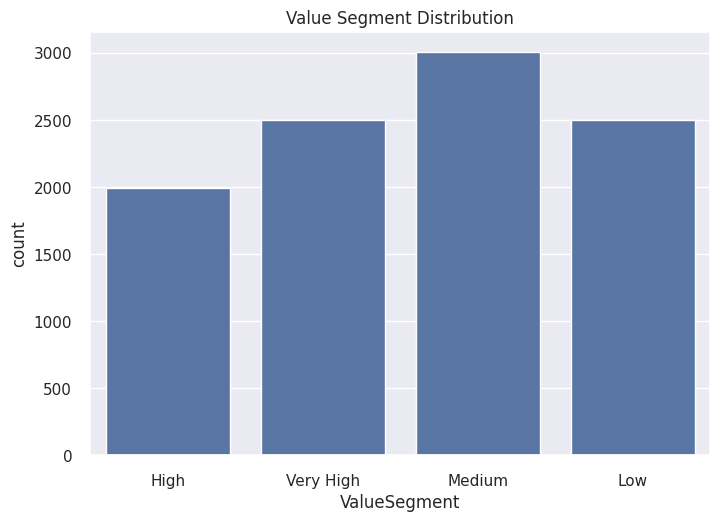

In [68]:

sns.countplot(x=df["ValueSegment"])                                             ## Creates a count plot for Value Segments
plt.title("Value Segment Distribution")                                         ## Clearly labels the chart to indicate what customer attribute is being analysed
plt.show()                                                                      ## Renders the count plot on screen


The below code creates a distribution plot for the AverageMonthlyLogins variable to understand how frequently customers log into the system on average each month. The histogram shows the count of customers across different login frequency ranges, while the overlaid KDE (kernel density estimate) curve provides a smooth representation of the overall distribution shape. This visualisation helps identify whether login activity is low, moderate, or high among customers, whether the distribution is skewed and whether there are potential clusters of user engagement levels.

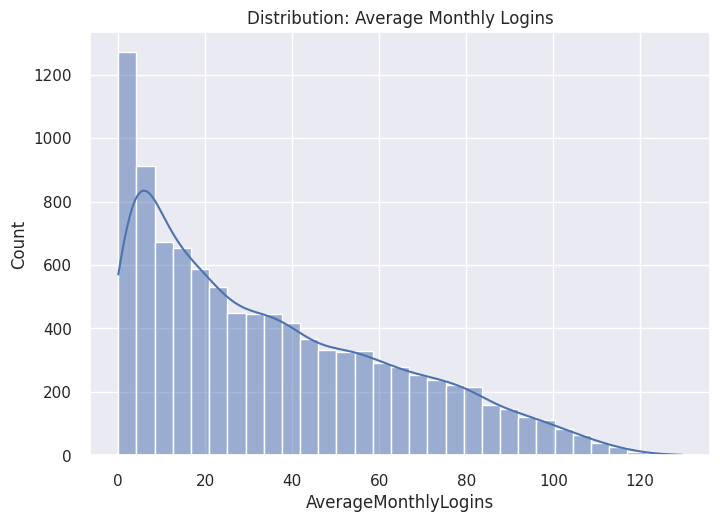

In [69]:

sns.histplot(df["AverageMonthlyLogins"], kde=True)                              ## Plots the histogram with KDE showing how many customers fall into each login-frequency interval.
plt.title("Distribution: Average Monthly Logins")                               ## Add a descriptive title
plt.show()                                                                      ## Display the chart


The below script visualises the distribution of the LoginTrend variable, which represents the change in a customer’s login frequency from the earliest recorded month to the most recent one. The histogram shows how many customers experienced increases, decreases, or no change in their login activity over time. The KDE (kernel density estimate) curve provides a smoothed outline of the distribution, making it easier to identify overall behavioural patterns such as declining activity, stable engagement, or growth in logins. This plot is useful for understanding customer engagement trends and detecting whether most users are becoming more or less active over time.

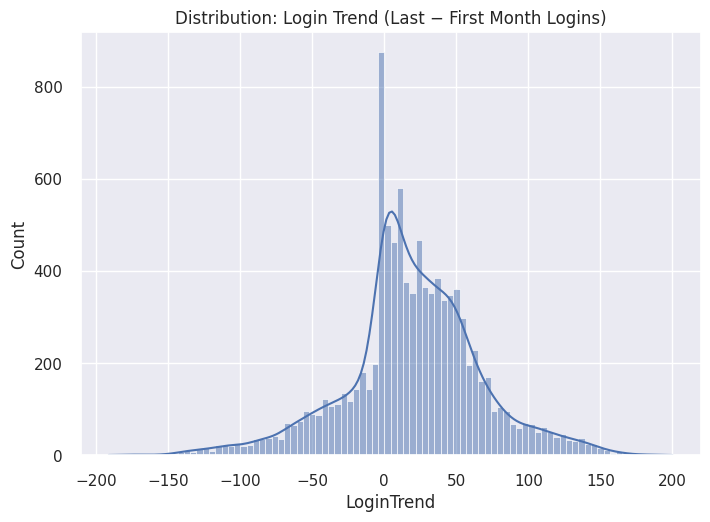

In [70]:

sns.histplot(df["LoginTrend"], kde=True)                                        ## Plot a histogram with KDE curve
plt.title("Distribution: Login Trend (Last − First Month Logins)")              ## Add a descriptive title
plt.show()                                                                      ## Display the chart


The below code visualises the distribution of the SupportIntensity metric, which measures how frequently customers open support tickets relative to their length of tenure. By plotting a histogram with an overlaid kernel density estimate (KDE), the graph shows whether most customers open support tickets rarely, occasionally, or very frequently. The shape of the distribution helps identify patterns such as highly active help seeking customers, outliers who generate excessive support load and general customer behaviour in terms of support usage. This analysis is useful for understanding product issues, service demand and customer satisfaction trends.

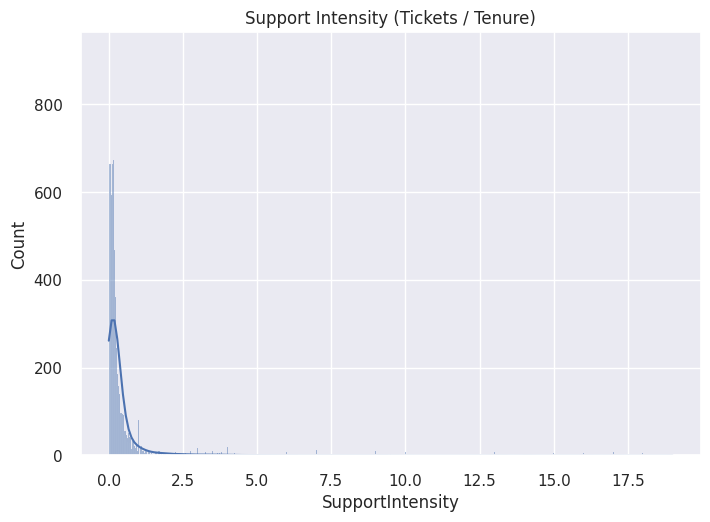

In [71]:

sns.histplot(df["SupportIntensity"], kde=True)                                  ## Plots a histogram of SupportIntensity with a KDE curve
plt.title("Support Intensity (Tickets / Tenure)")                               ## Adds a clear and descriptive title
plt.show()                                                                      ## Displays the plot


This line of code checks whether the dataset contains any column related to customer churn by searching for the word “churn” within all column names. Because churn data is not always included in every dataset, this step helps confirm whether a churn variable exists before performing churn analysis, modelling or visualisation. The code returns a list of matching column names, allowing the user to verify if churn features are present or if they need to be created or derived.

In [72]:

[col for col in df.columns if "churn" in col.lower()]           ## The code scans all column names, converts them to lowercase, checks which ones contain the word ‘churn’, and returns a list of those matching columns.


['Churn']

Below written code generates a count plot to visualise the distribution of churned versus non-churned customers. A count plot displays the number of observations in each category, so using it on the Churn column allows you to see how many customers stayed and how many left the service. This visualisation helps determine whether the dataset is balanced or imbalanced, which is important for understanding customer behaviour patterns and for developing predictive models.

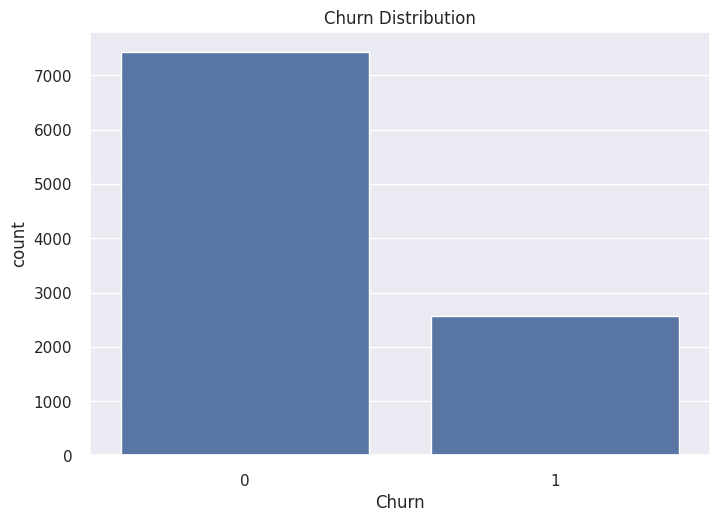

In [73]:

sns.countplot(x=df["Churn"])                                                    ## Creates a count plot showing frequency of each churn category
plt.title("Churn Distribution")                                                 ## Adds a descriptive title
plt.show()                                                                      ## Displays the chart


The following written code creates a boxplot to compare the distribution of customer tenure (in months) between churned and non-churned customers. By visualising both groups side-by-side, the plot helps reveal whether customers who leave the service typically have shorter tenures, longer tenures or similar tenure lengths compared to those who stay. Boxplots also highlight medians, quartiles and potential outliers, making this chart useful for identifying behavioural differences that might influence churn decisions.

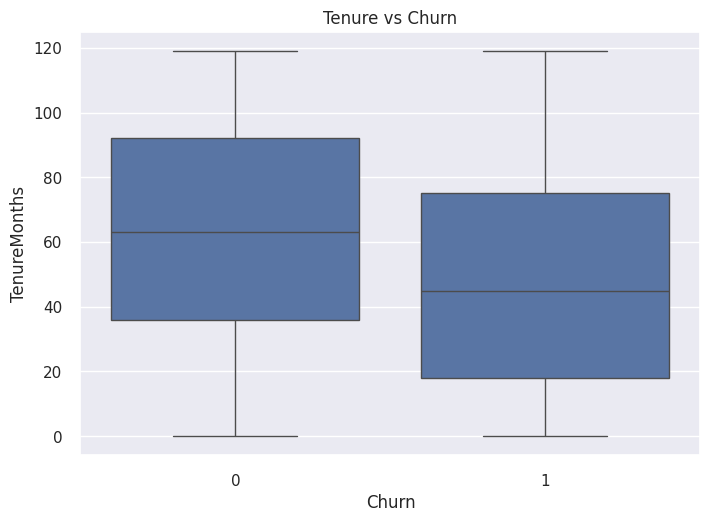

In [74]:

sns.boxplot(x=df["Churn"], y=df["TenureMonths"])                                ## Creates a boxplot comparing tenure across churn categories
plt.title("Tenure vs Churn")                                                    ## Adds a descriptive title
plt.show()                                                                      ## Displays the plot


Below added code generates a boxplot to compare the distribution of monthly revenue between customers who have churned and those who have not. By plotting both groups side by side, the visualization reveals whether churned customers tend to generate lower, higher or similar revenue compared to retained customers. Boxplots help illustrate central tendency (median), spread (quartiles) and outliers, making it easy to see how customer revenue patterns differ across churn categories. This is useful for understanding the financial impact of churn and identifying high value at risk customers.

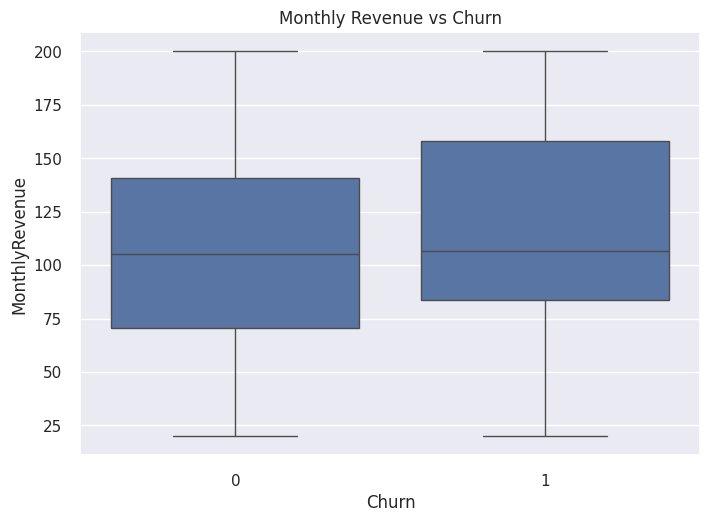

In [75]:

sns.boxplot(x=df["Churn"], y=df["MonthlyRevenue"])                              ## Creates a boxplot comparing monthly revenue across churn groups
plt.title("Monthly Revenue vs Churn")                                           ## Adds a descriptive title
plt.show()                                                                      ## Displays the plot



The below code produces a scatter plot that visualizes the relationship between MonthlyRevenue and MonthlyProfit, allowing you to see how profit changes as revenue increases across customers. The plot reveals a clear upward trend, indicating that higher revenue generally corresponds to higher profit, while also showing the variability and spread in profit levels at different revenue points, which helps in understanding financial performance patterns and identifying any inconsistencies or outliers.

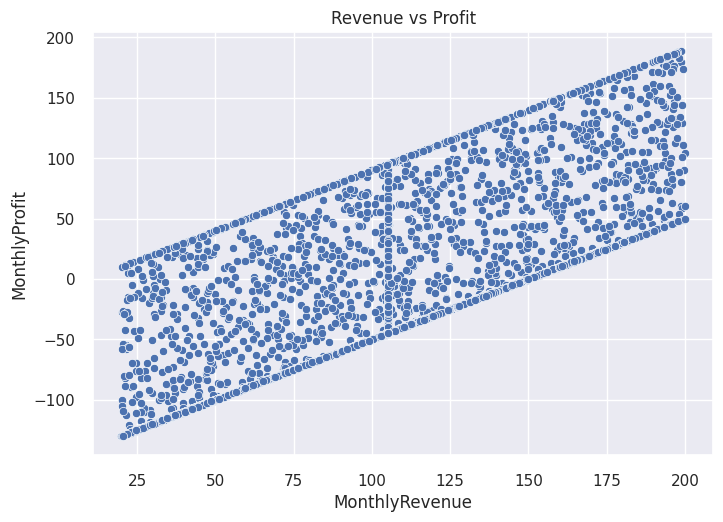

In [76]:
## RFM, Revenue, and Profit Relationships

sns.scatterplot(x=df["MonthlyRevenue"], y=df["MonthlyProfit"])                  ## Plots a scatter plot comparing Monthly Revenue and Monthly Profit
plt.title("Revenue vs Profit")                                                  ## Clearly labels the plot so viewers know the financial metrics being compared
plt.show()                                                                      ## Renders the scatter plot on the screen


The below code generates a scatter plot to explore the relationship between RFMScore and MonthlyProfit, plotting each customer’s score against their profit value. This visualization helps reveal whether higher RFM scores indicating stronger recent activity, frequency, and monetary value tend to correspond with higher profitability. Although the points appear widely dispersed, the plot helps identify general patterns, clusters, or inconsistencies in how customer value (via RFM) aligns with profit performance.

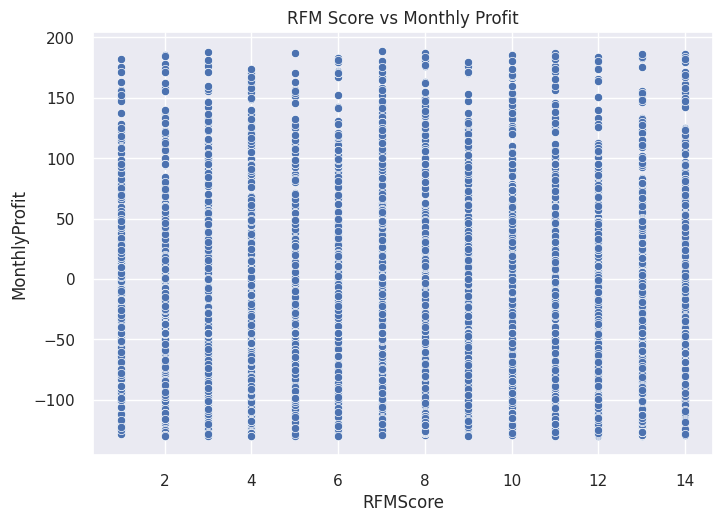

In [77]:

sns.scatterplot(x=df["RFMScore"], y=df["MonthlyProfit"])                        ## Draw a scatter plot of RFM Score vs Monthly Profit
plt.title("RFM Score vs Monthly Profit")                                        ## Clearly labels the plot so viewers know what relationship is being examined
plt.show()                                                                      ## Renders the scatter plot on the screen


The below code produces a strip plot that visualizes the relationship between UsageChangePct and RFMScore, using jitter to spread out overlapping points and improve readability. Each point represents a customer and is color coded based on their ComplaintCategory, allowing you to observe how different complaint types are distributed across usage changes and RFM score levels. This plot helps reveal whether certain complaint categories cluster around specific usage behavior or customer value segments, while also showing the overall spread and patterns in usage change relative to customer scoring.

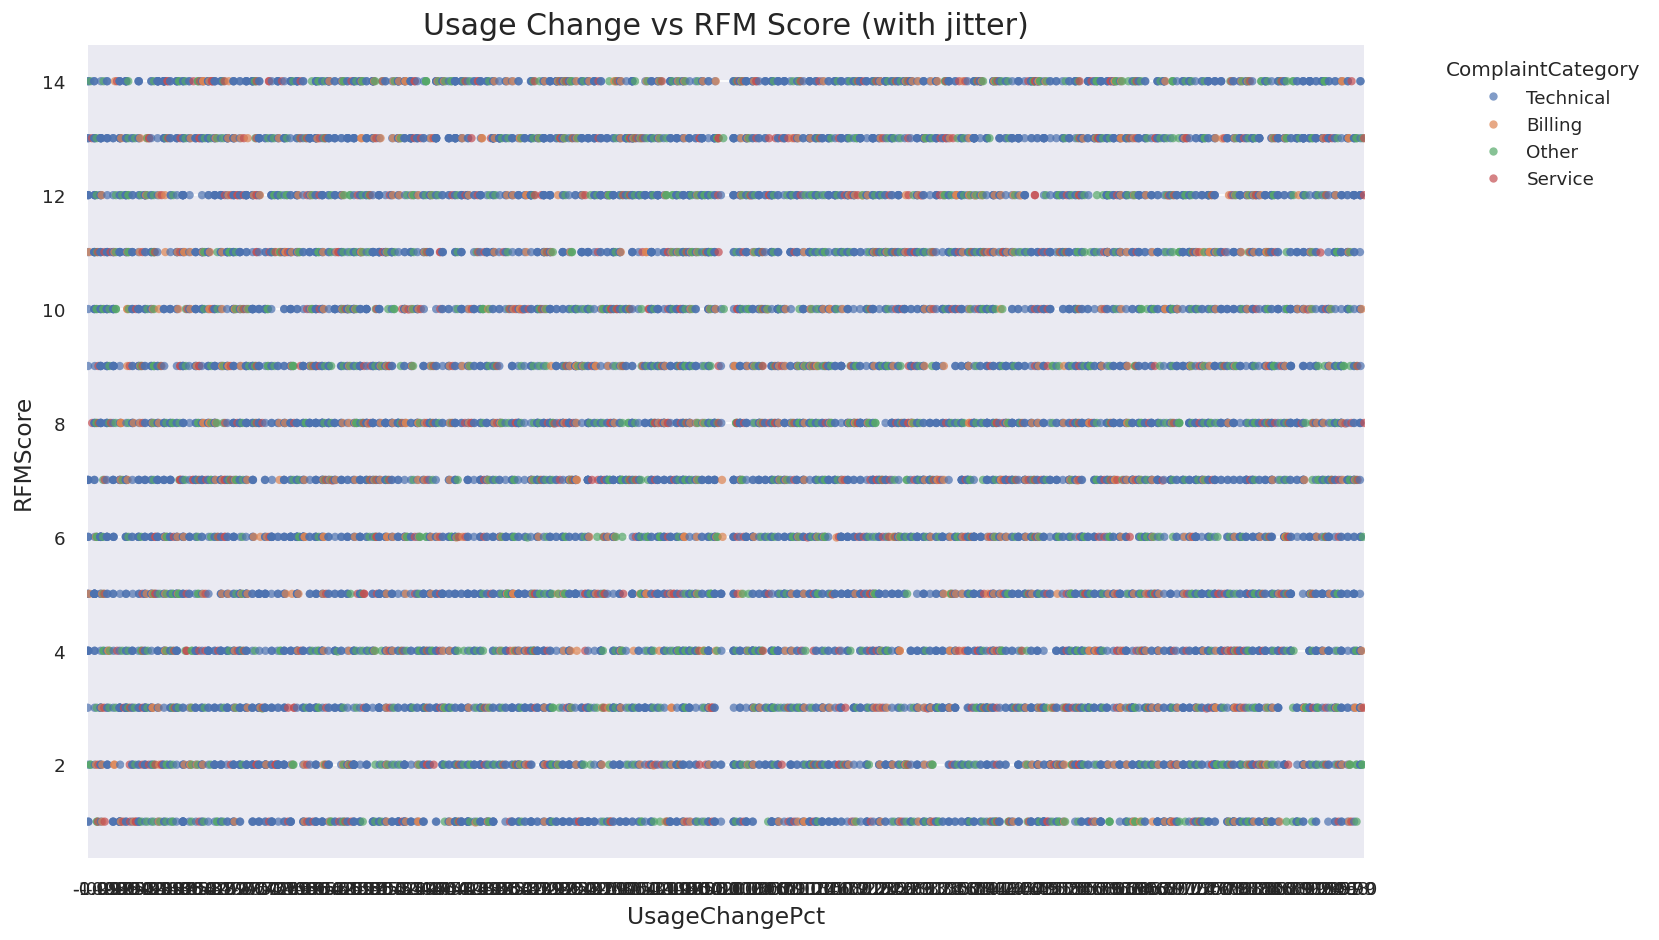

In [78]:

plt.figure(figsize=(14, 8), dpi=120)                                            ## Sets up a large, high-resolution figure

## Draws a jittered strip plot

sns.stripplot(
    data=df,
    x="UsageChangePct",
    y="RFMScore",
    hue="ComplaintCategory",
    dodge=True,
    jitter=0.25,
    alpha=0.7,
    size=5
)
## Clearly labels the axes and the chart for interpretation

plt.title("Usage Change vs RFM Score (with jitter)", fontsize=18)
plt.xlabel("UsageChangePct", fontsize=14)
plt.ylabel("RFMScore", fontsize=14)
plt.legend(title="ComplaintCategory", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


The below code performs a segment level financial analysis by calculating the average monthly profit for each customer tenure segment. It groups customers into categories such as New, Growing, Established and Loyal, then computes the average profit for each group. The results are visualised as a bar chart, making it easy to compare profitability across different stages of the customer lifecycle. This helps identify which tenure groups contribute the most profit, which segments may need strategic focus and how financial performance varies as customers stay longer with the company.

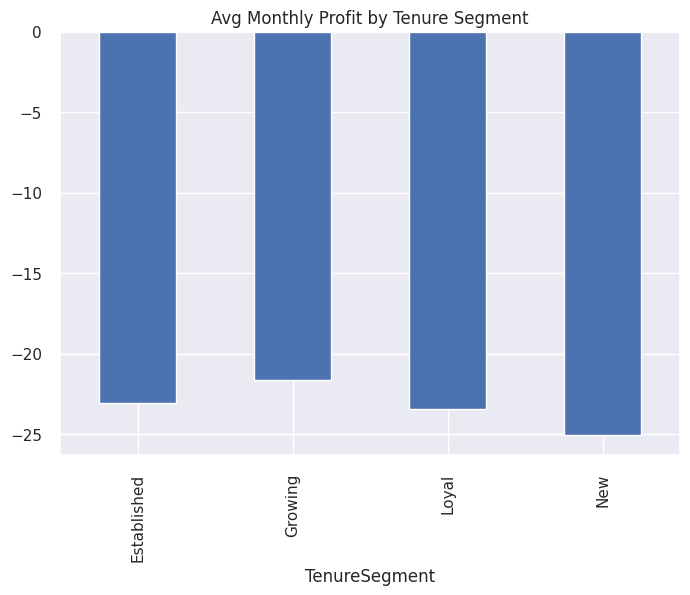

In [79]:

df.groupby("TenureSegment")["MonthlyProfit"].mean().plot(kind="bar")            ## Group data by Tenure Segment and plots the results as a bar chart
plt.title("Avg Monthly Profit by Tenure Segment")                               ## Add a descriptive title
plt.show()                                                                      ## Display the plot


The below code analyses how average monthly revenue varies across different age groups. It groups all customers by their assigned AgeGroup category, for example: under 30, 30–44, 45–59 and 60+, and calculates the mean monthly revenue for each group. The results are displayed as a bar chart, allowing easy comparison of revenue contribution across age demographics. This type of analysis helps identify which age groups generate the most value, informing marketing strategies and targeted business decisions.

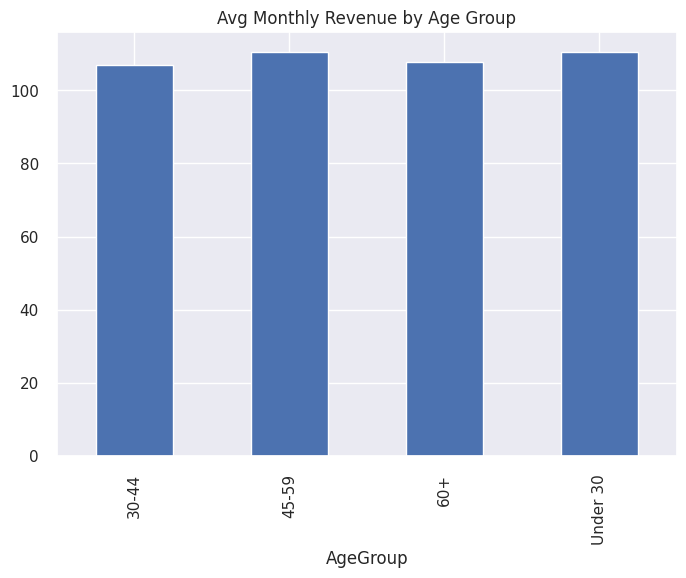

In [80]:

df.groupby("AgeGroup")["MonthlyRevenue"].mean().plot(kind="bar")                ## Groups customers by Age Group and computes mean revenue and converts the result to a bar chart
plt.title("Avg Monthly Revenue by Age Group")                                   ## Adds a title to the chart
plt.show()                                                                      ## Displays the plot


Sarvesh Pisal (125119869)
Led the cleaning of the monthly_logins dataset, including standardising month. Aslo helped in cleaning the customer_info dataset.
Implemented handling of missing values, invalid entries
Developed the logic for reshaping the wide login data
Wrote detailed documentation.

Srushti R Shetti (125121632)
Cleaned the customer_behavior.csv file including categorical standardisation and numeric range validation.
Created the rounding, date formatting, and categorical mapping logic (e.g., FamilyPlan, ComplaintCategory).
Implemented transformations for MonthlyCost, RFMScore, UsageChangePct, CompetitorIndex, and ticket metrics.
Contributed detailed explanations for the behaviour cleaning steps.

Aditya More (125122479)
Cleaned the customer_info dataset, including handling demographics, correcting dates, and parsing contract data.
Designed and executed the merging strategy.
Validated referential integrity on CustomerID and ensured no duplication
Documented the merging methodology and checks.

Sahil Kamble  (125104903)
Implemented most of the  derived fields, including financial temporal metrics and segmentation.
Developed formulas, assumptions, and validation logic for derived fields
Produced documentation detailing each derived feature and its purpose.

Kartik Shah (124119829)
Performed the complete EDA, including distributions, correlations, and customer segmentation insights.
Created visualisations such as scatterplots, histograms, heatmaps, and time-series charts.
Improved clarity of charts.
Wrote descriptive narratives interpreting the charts and insights.

Gayatri Satyakar (125104914)
created the notebook structure, combining Markdown explanations
Wrote the introduction, project overview, dataset descriptions.
Ensured the notebook followed the submission guidelines (naming conventions, references section & contribution).
Performed final proofreading, cross-checking, and quality assurance of the entire notebook.




**References:**

1. McKinney, W. (2017). Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython. 2nd edn. O’Reilly Media.
(Foundational book by the creator of Pandas discussing real-world data cleaning & analysis techniques.)

2. VanderPlas, J. (2016). Python Data Science Handbook. O’Reilly Media.
Available at: https://jakevdp.github.io/PythonDataScienceHandbook/

(Covers essential workflows including feature engineering, visualisation, and NumPy/Pandas operations.)

3. Oliphant, T. E. (2015). Guide to NumPy. 2nd edn. Continuum Analytics.
(A comprehensive resource explaining numerical computation concepts used throughout the project.)

4. Plotly Technologies Inc. (2024). Plotly Python Graphing Library. Available at: https://plotly.com/python/
Murach, J. (2023). Murach’s Python Programming. Murach Books.
(A practical reference covering Python programming foundations, including data structures, functions, and coding best practices relevant to the project.)

5. OpenAI (2025). ChatGPT (Version 5.1) [Large language model]. Available at: https://chat.openai.com/ (Accessed: [24/11/2025]).
A small portion of this project’s documentation and explanation text was supported by ChatGPT (OpenAI, 2025). Prompts used focused strictly on clarifying Python code functionality and improving the readability of project explanations. All analysis, coding decisions, and interpretations were performed by the student group.